<a href="https://colab.research.google.com/github/jiamin-jamie-Chen/CHEN-Jiamin_1155239821_5962B-Final-Project_/blob/main/CHEN%20Jiamin_1155239821_5962B%20Final%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Read after uploading the file
df = pd.read_csv("digital_marketing_campaign_dataset.csv")

# View basic information
print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Age  Gender  Income CampaignChannel CampaignType      AdSpend  \
0        8000   56  Female  136912    Social Media    Awareness  6497.870068   
1        8001   69    Male   41760           Email    Retention  3898.668606   
2        8002   46  Female   88456             PPC    Awareness  1546.429596   
3        8003   32  Female   44085             PPC   Conversion   539.525936   
4        8004   60  Female   83964             PPC   Conversion  1678.043573   

   ClickThroughRate  ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
0          0.043919        0.088031              0       2.399017    7.396803   
1          0.155725        0.182725             42       2.917138    5.352549   
2          0.277490        0.076423              2       8.223619   13.794901   
3          0.137611        0.088004             47       4.540939   14.688363   
4          0.252851        0.109940              0       2.046847   13.993370   

   SocialShares  EmailOpens  Ema

In [ ]:
# Step 2: Data cleaning
# Check for missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Check for outliers in numerical variables
df.describe()



CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


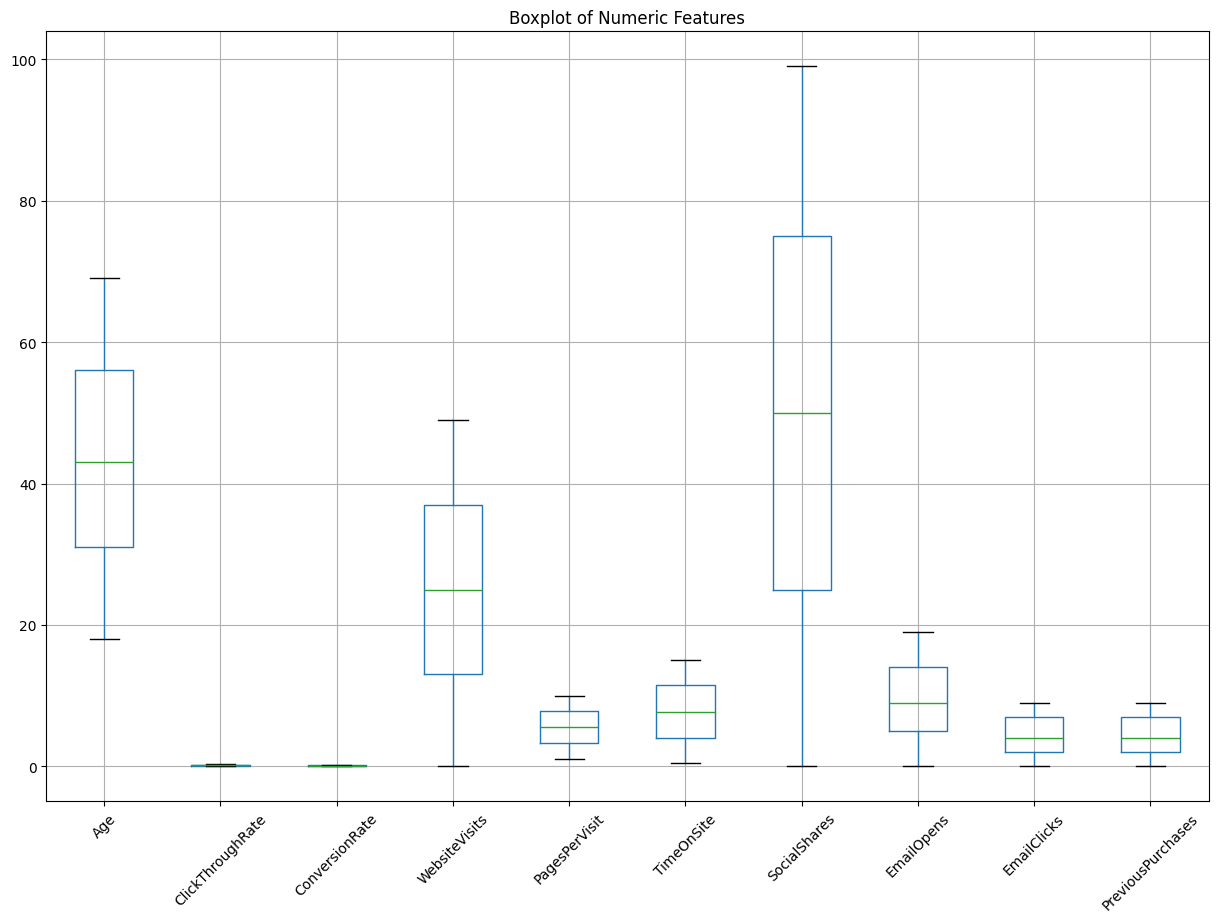

In [ ]:
# Check for outliers using a box-and-whisker plot
numeric_cols = ['Age','ClickThroughRate','ConversionRate',
                'WebsiteVisits','PagesPerVisit','TimeOnSite',
                'SocialShares','EmailOpens','EmailClicks',
                'PreviousPurchases']

plt.figure(figsize=(15,10))
df[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

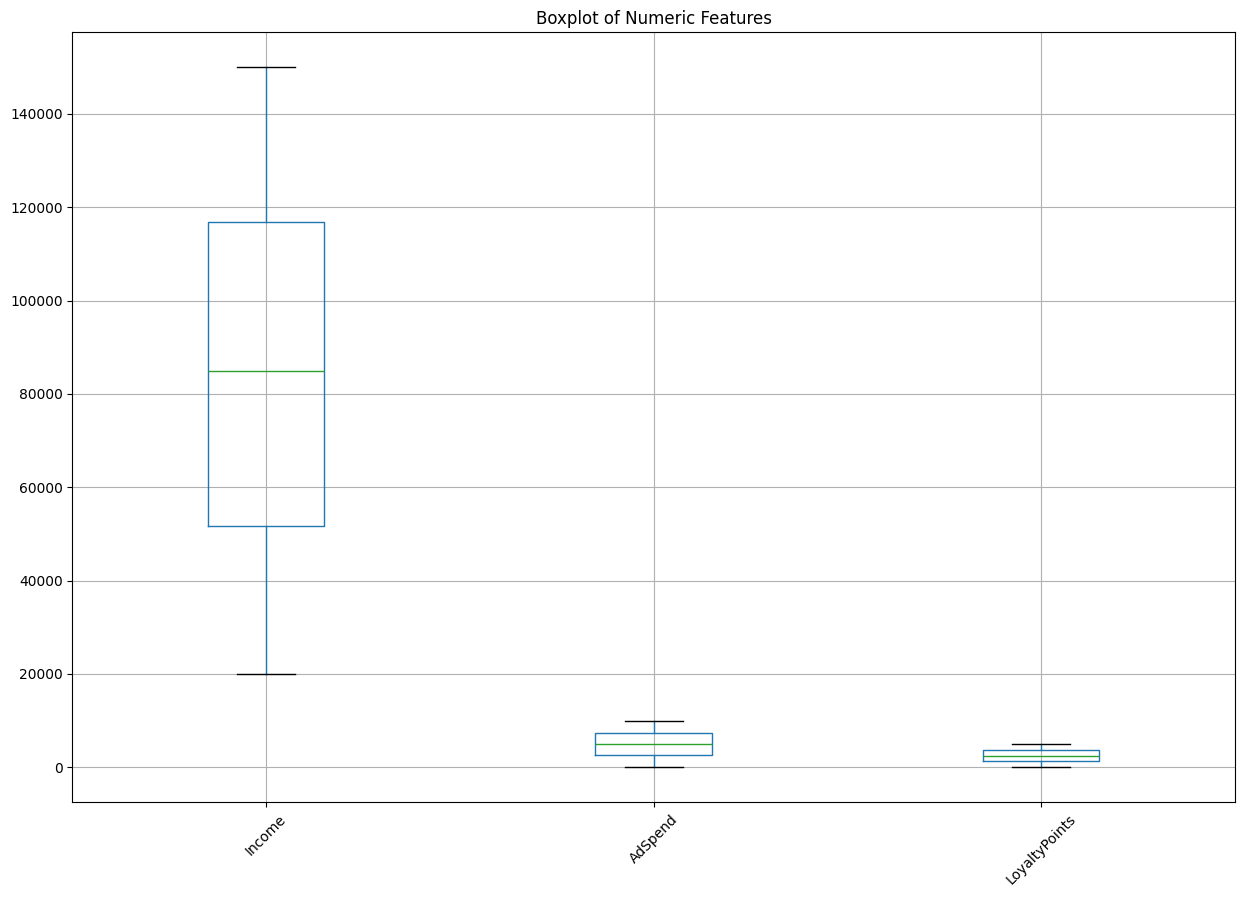

In [ ]:
# Checking for outliers in box plots
numeric_cols = ['Income','AdSpend','LoyaltyPoints']

plt.figure(figsize=(15,10))
df[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outlier_rows = np.where(z_scores > 3)[0]   # The threshold is usually set to 3
print("Z-score outliers:", len(outlier_rows))

Z-score 检测到的异常值行数: 0


In [ ]:
# Detecting outliers using the IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

Income: 0 个异常值
AdSpend: 0 个异常值
LoyaltyPoints: 0 个异常值


不同性别的平均转化率:
 Gender
Female    0.876214
Male      0.876938
Name: Conversion, dtype: float64


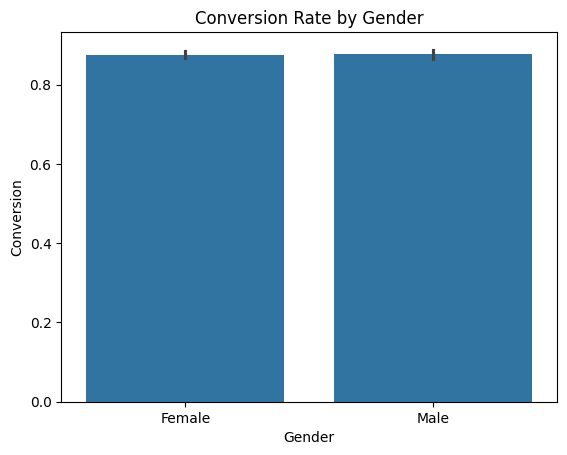

In [ ]:
# Step 1: Gender 与 Conversion 的关系
gender_conv = df.groupby('Gender')['Conversion'].mean()
print("不同性别的平均转化率:\n", gender_conv)

sns.barplot(x='Gender', y='Conversion', data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Conversion Rate by Gender")
plt.show()

/tmp/ipykernel_941/3006858599.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_conv = df.groupby('AgeGroup')['Conversion'].mean().reset_index()


   AgeGroup  Conversion
0  [20, 30)    0.875932
1  [30, 40)    0.873257
2  [40, 50)    0.887619
3  [50, 60)    0.869251
4  [60, 70)    0.876933
5  [70, 80)         NaN


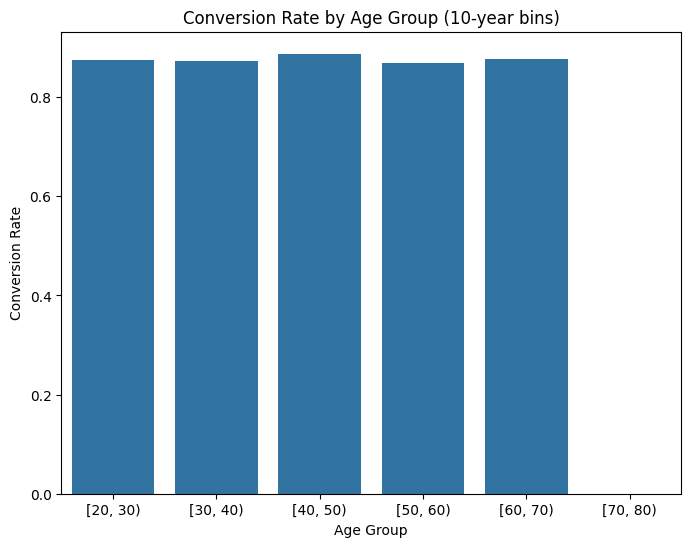

In [ ]:
# Group by age (in 10-year intervals)
df['AgeGroup'] = pd.cut(df['Age'], bins=range(20, 81, 10), right=False)

# Calculate the average conversion rate by age group
age_group_conv = df.groupby('AgeGroup')['Conversion'].mean().reset_index()

print(age_group_conv)

# Create a bar chart showing age groups versus conversion rates
plt.figure(figsize=(8,6))
sns.barplot(data=age_group_conv, x='AgeGroup', y='Conversion')
plt.title("Conversion Rate by Age Group (10-year bins)")
plt.ylabel("Conversion Rate")
plt.xlabel("Age Group")
plt.show()

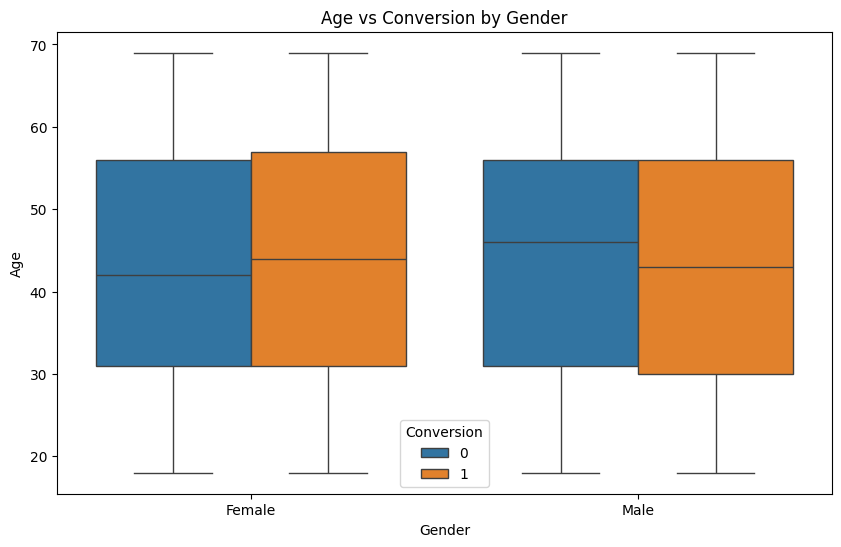

In [ ]:

# The impact of the interaction between age and gender on conversion
plt.figure(figsize=(10,6))
sns.boxplot(x='Gender', y='Age', hue='Conversion', data=df)
plt.title("Age vs Conversion by Gender")
plt.show()

不同渠道的平均转化率:
   CampaignChannel  Conversion
0           Email    0.870263
1             PPC    0.882779
2        Referral    0.883072
3             SEO    0.876774
4    Social Media    0.868334


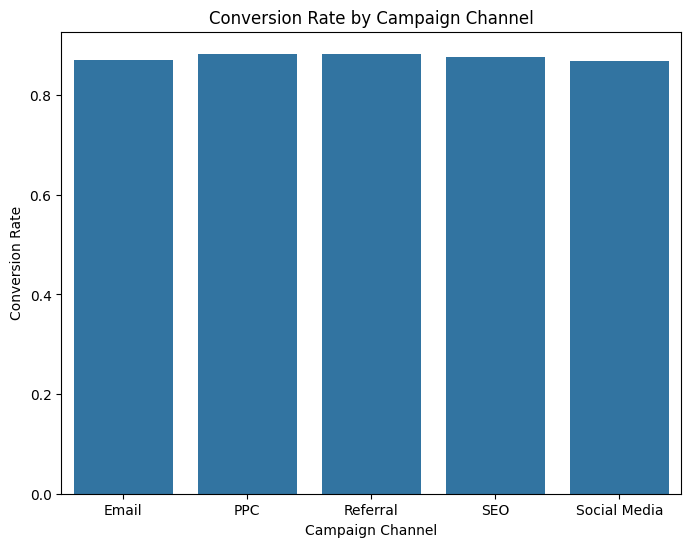

In [ ]:
# Conversion rates by Campaignchannel
channel_conv = df.groupby('CampaignChannel')['Conversion'].mean().reset_index()
print("不同渠道的平均转化率:\n", channel_conv)

plt.figure(figsize=(8,6))
sns.barplot(data=channel_conv, x='CampaignChannel', y='Conversion')
plt.title("Conversion Rate by Campaign Channel")
plt.ylabel("Conversion Rate")
plt.xlabel("Campaign Channel")
plt.show()

不同渠道的平均数值特征:
   CampaignChannel      AdSpend  WebsiteVisits  PreviousPurchases  TimeOnSite  \
0           Email  5055.604272      24.878613           4.559409    7.679983   
1             PPC  4954.221741      24.155287           4.420544    7.841258   
2        Referral  5034.042284      24.890634           4.484584    7.651172   
3             SEO  4994.131533      24.740000           4.519355    7.617339   
4    Social Media  4965.321428      25.125741           4.447005    7.852198   

   ClickThroughRate  
0          0.155609  
1          0.158307  
2          0.151673  
3          0.153150  
4          0.155523  


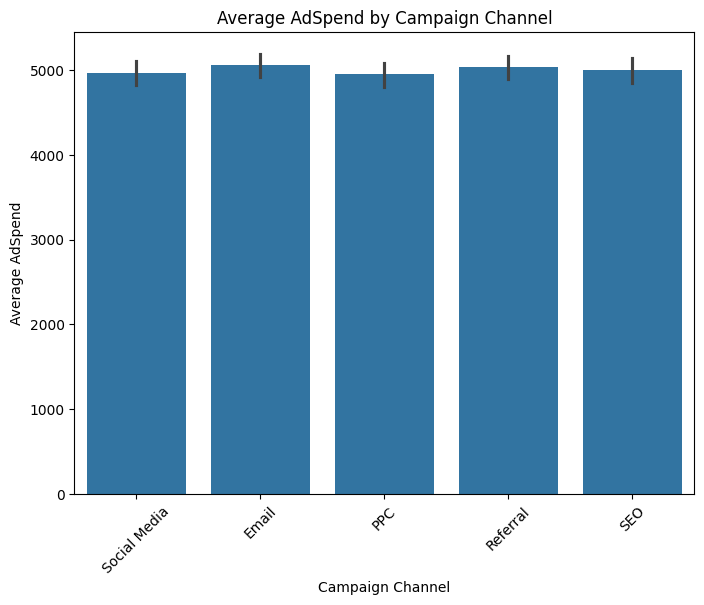

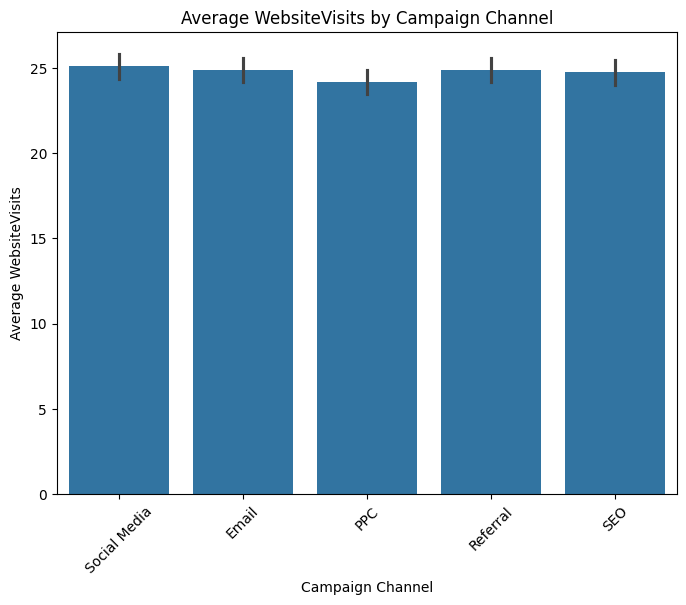

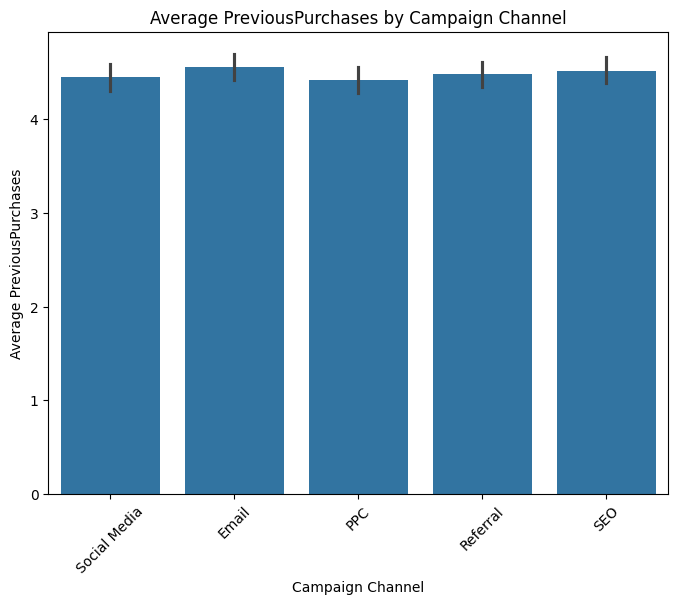

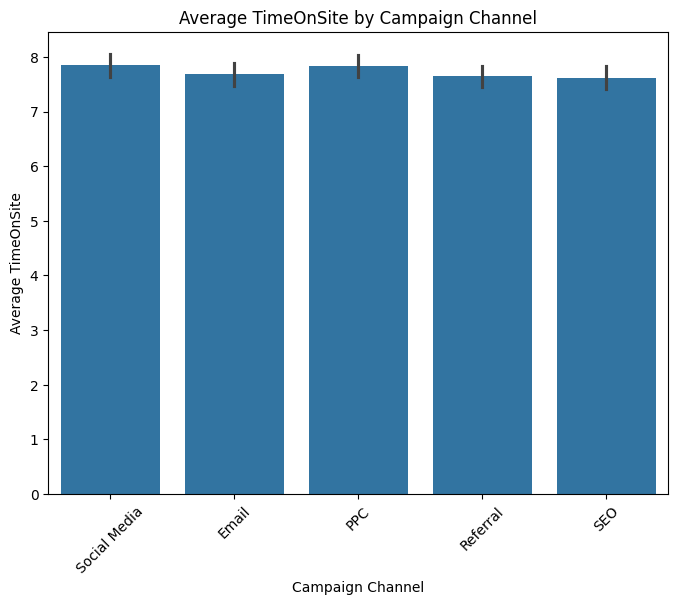

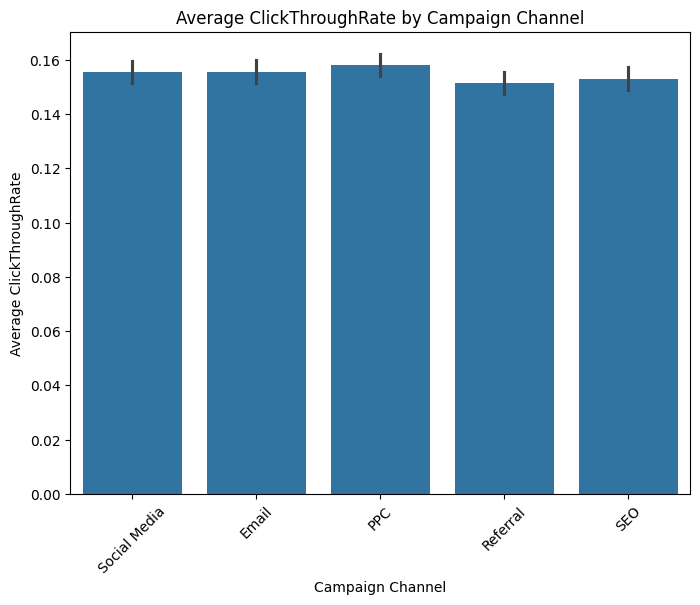

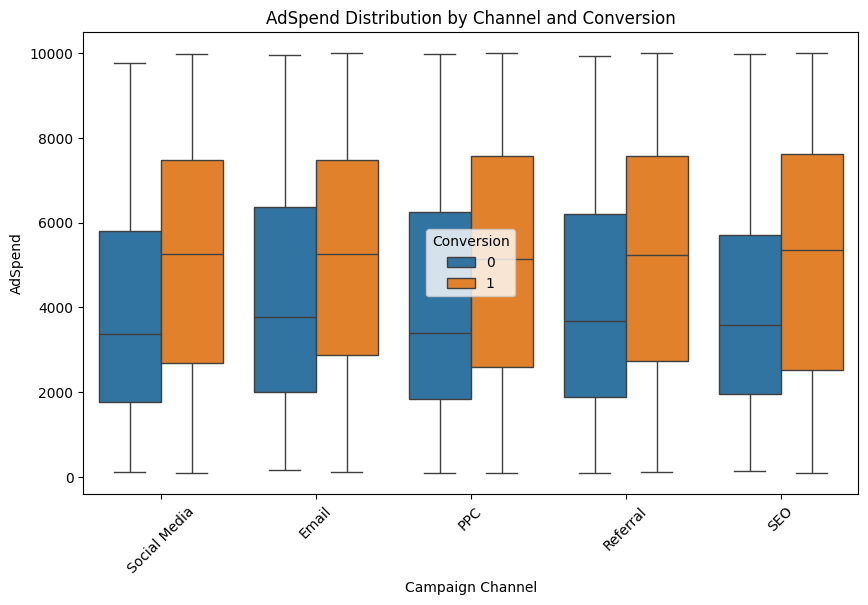

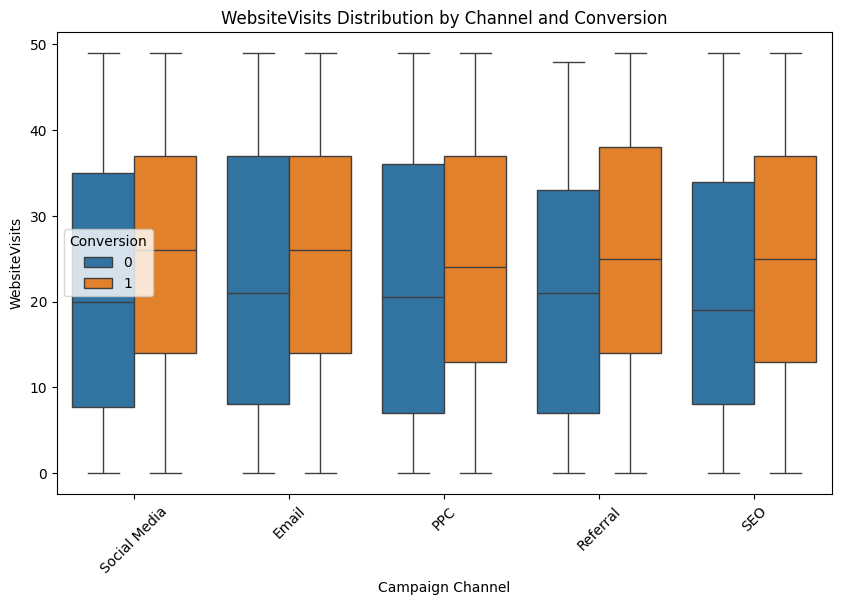

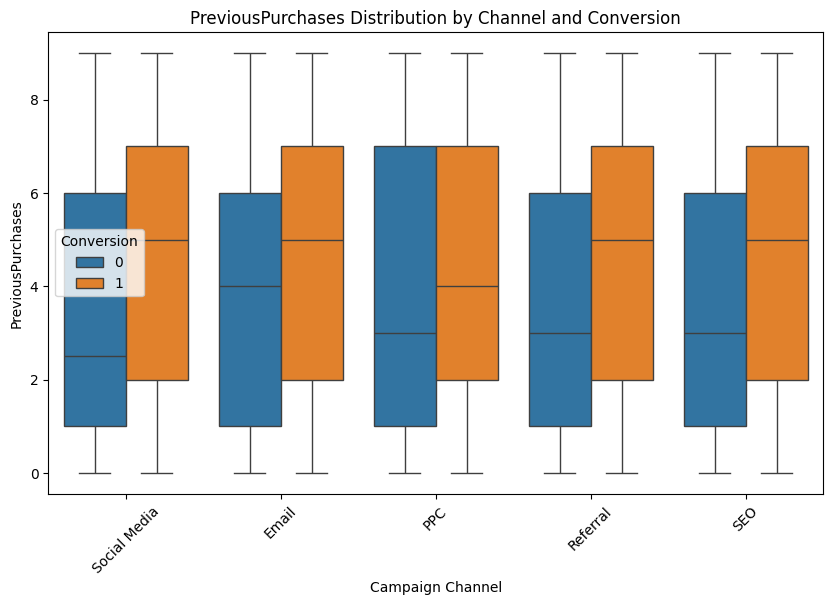

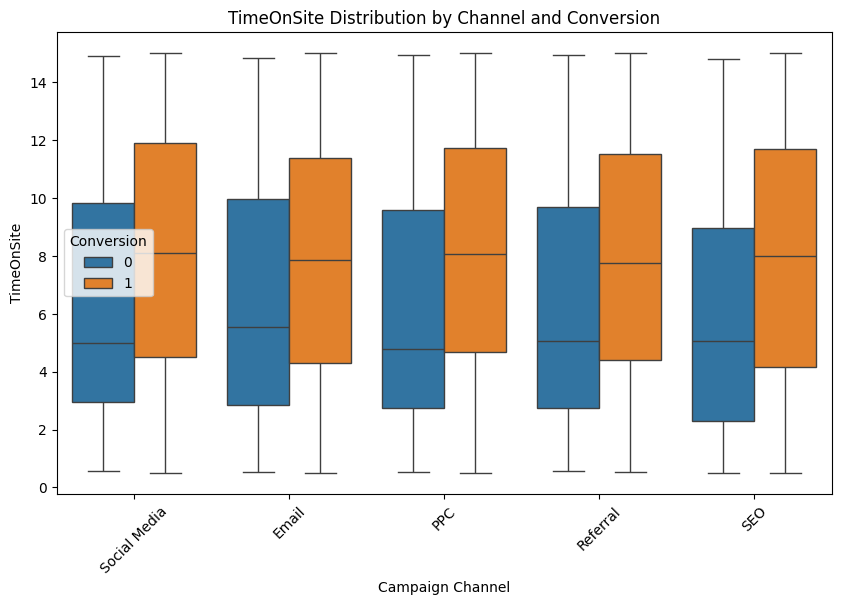

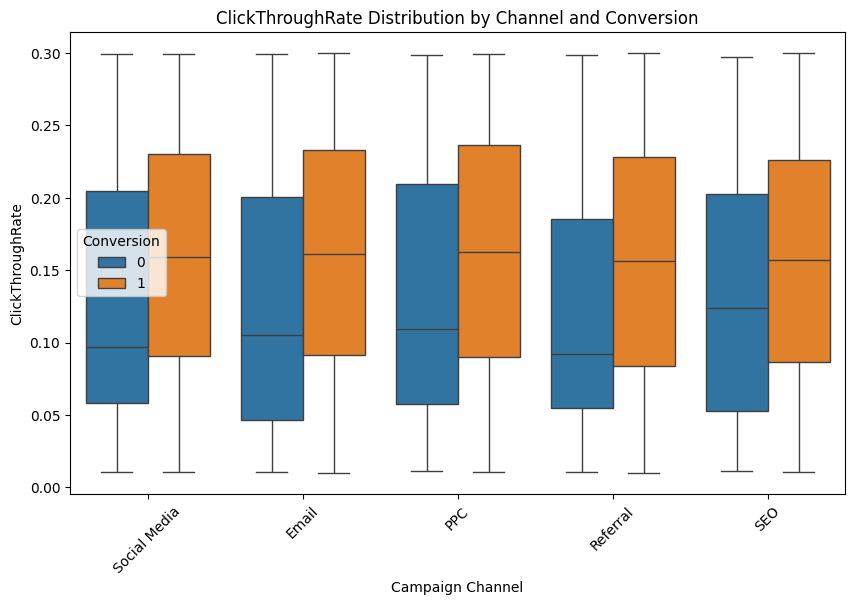

In [ ]:
# Numerical variables to be analysed
numeric_vars = ['AdSpend','WebsiteVisits','PreviousPurchases','TimeOnSite','ClickThroughRate']

# Calculate the average by channel
channel_stats = df.groupby('CampaignChannel')[numeric_vars].mean().reset_index()
print("不同渠道的平均数值特征:\n", channel_stats)

# Visualise the relationship between each variable and the channel
for var in numeric_vars:
    plt.figure(figsize=(8,6))
    sns.barplot(data=df, x='CampaignChannel', y=var, estimator='mean')
    plt.title(f"Average {var} by Campaign Channel")
    plt.ylabel(f"Average {var}")
    plt.xlabel("Campaign Channel")
    plt.xticks(rotation=45)
    plt.show()

# If you wish to examine the relationship between conversion rates and these variables simultaneously, you can perform an interaction analysis
for var in numeric_vars:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x='CampaignChannel', y=var, hue='Conversion')
    plt.title(f"{var} Distribution by Channel and Conversion")
    plt.ylabel(var)
    plt.xlabel("Campaign Channel")
    plt.legend(title="Conversion")
    plt.xticks(rotation=45)
    plt.show()

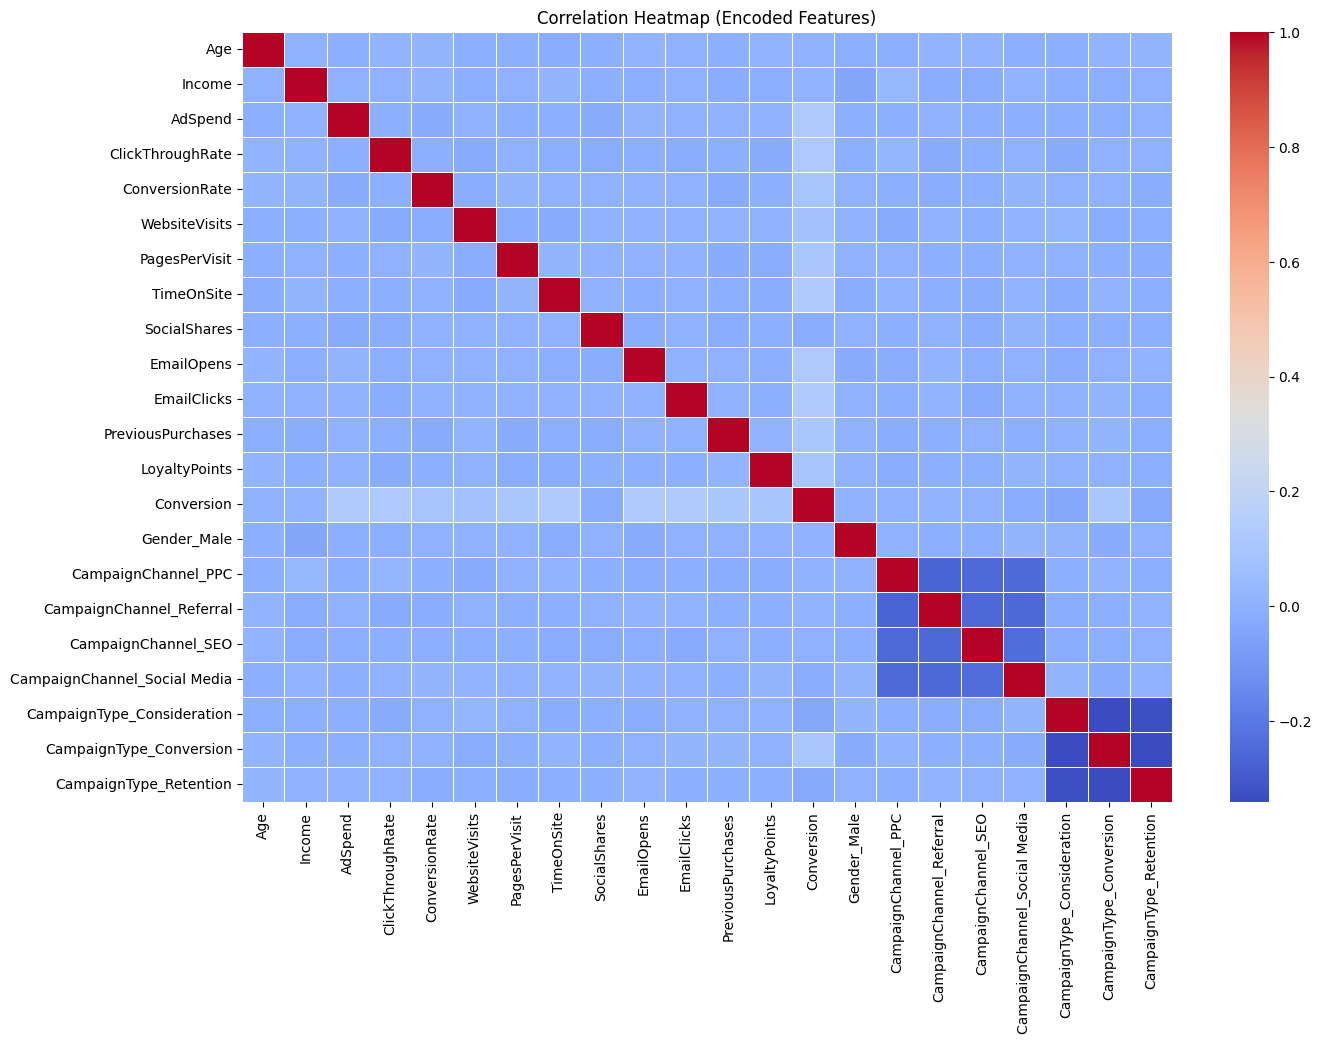

In [ ]:
# Remove unnecessary columns
df = df.drop(columns=['CustomerID','AdvertisingPlatform','AdvertisingTool'], errors='ignore')

# Delete AgeGroup
df = df.drop(columns=['AgeGroup'], errors='ignore')

# Coding categorical variables
df_encoded = pd.get_dummies(df, columns=['Gender','CampaignChannel','CampaignType'], drop_first=True)

# Ensure that all columns are set to "float"
df_encoded = df_encoded.astype(float)

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Create a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()


Optimization terminated successfully.
         Current function value: 0.294193
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 6400
Model:                          Logit   Df Residuals:                     6378
Method:                           MLE   Df Model:                           21
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2128
Time:                        13:23:10   Log-Likelihood:                -1882.8
converged:                       True   LL-Null:                       -2391.8
Covariance Type:            nonrobust   LLR p-value:                4.252e-202
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            1.5092      0.143     10.572      0.000

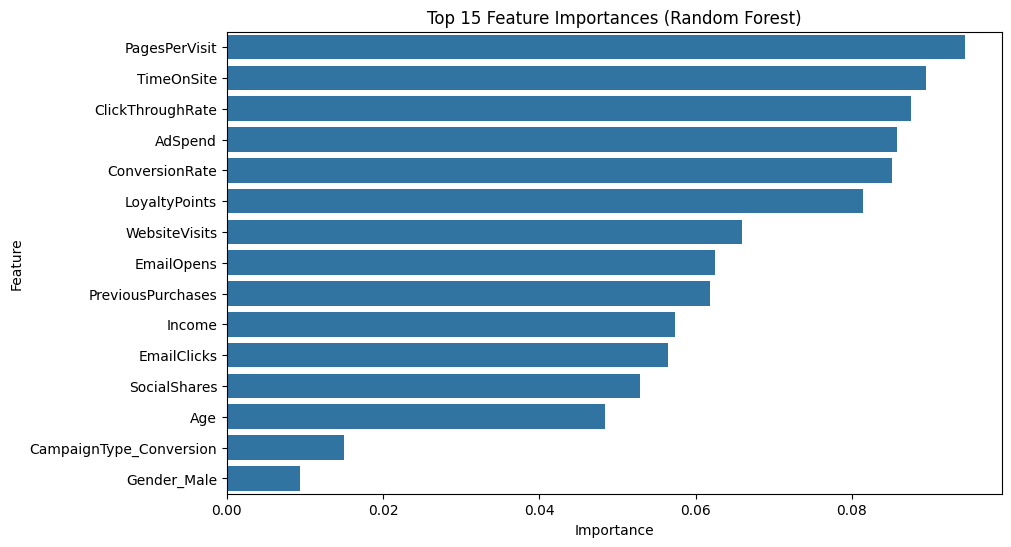

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Features and target variables
X = df_encoded.drop(columns=['Conversion'])
y = df_encoded['Conversion']

# Standardisation of numerical variables
numeric_cols = ['Age','Income','AdSpend','WebsiteVisits','PagesPerVisit','TimeOnSite',
                'SocialShares','EmailOpens','EmailClicks','PreviousPurchases','LoyaltyPoints','ClickThroughRate']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split the training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Logistic Regression (statsmodels, returns p-values)
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

# Step 5: Random Forest (scikit-learn)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importance Visualisation (Random Forest)
importances = rf.feature_importances_
feat_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_importances.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()


Percentile threshold:
PreviousPurchases ≥ 0.8706980657458213
LoyaltyPoints ≥ 0.8466485833968576
TimeOnSite ≥ 0.9517520412591642
Number of high-value users: 29
Examples of high-value users:
      PreviousPurchases  LoyaltyPoints  TimeOnSite  Conversion_Prob
7737           1.216969       1.101644    1.054224            0.900
3328           1.563240       1.166704    1.137871            0.960
3496           1.563240       1.471020    1.246011            0.930
2875           1.216969       1.589948    1.299840            0.895
7489           0.870698       1.148516    1.697446            0.945


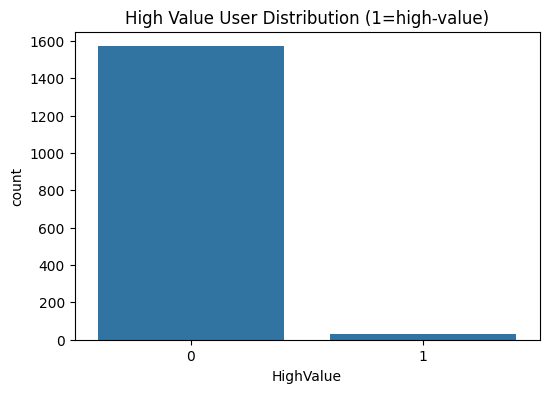

In [ ]:
# Include predicted probabilities in the dataset (based on the test set)
df_test = X_test.copy()
df_test['Conversion'] = y_test.values
df_test['Conversion_Prob'] = y_prob_rf

# Calculate the quantile threshold (based on the distribution of the test set data)
purchase_threshold = df_test['PreviousPurchases'].quantile(0.75)
loyalty_threshold = df_test['LoyaltyPoints'].quantile(0.75)
time_threshold = df_test['TimeOnSite'].quantile(0.75)

print("Percentile threshold:")
print("PreviousPurchases ≥", purchase_threshold)
print("LoyaltyPoints ≥", loyalty_threshold)
print("TimeOnSite ≥", time_threshold)

# Set rules for high-value users
df_test['HighValue'] = (
    (df_test['Conversion_Prob'] >= 0.8) &
    (df_test['PreviousPurchases'] >= purchase_threshold) &
    (df_test['LoyaltyPoints'] >= loyalty_threshold) &
    (df_test['TimeOnSite'] >= time_threshold)
).astype(int)

# Create a customer profile
high_value_users = df_test[df_test['HighValue'] == 1]

print("Number of high-value users:", high_value_users.shape[0])
print("Examples of high-value users:")
print(high_value_users[['PreviousPurchases','LoyaltyPoints','TimeOnSite','Conversion_Prob']].head())

# Visualising the distribution of high-value users
plt.figure(figsize=(6,4))
sns.countplot(x='HighValue', data=df_test)
plt.title("High Value User Distribution (1=high-value)")
plt.show()
